## The First Formal Tool: Univariate Analysis
#### Univariate means one variable. Univariate analysis means we will only analyse one variable
#### This approach may be too simple for realistic analysis, but in practice, it's actually quite effective. 
#### In many cases, we can narrow down our analysis to one single important input by assuming that any other variables are independent, meaning that values outside variable affects the value of a given data point. This is assumption that is almost never true, but it often works out well enough in practice that we can perform a reasonable statistical analysis regardless.

### Distributions and Histograms
#### When looking at one-dimensional data, our focus is on the distribution of that data. A simple way to think of a distribution is the shape of the data. That is, how often do we see any particular value in the dataset?
- #### A discrete variable has a finite and known number of possible values. By contrast, a continuous variable has an infinite number of possible values. When building a histogram from a continuous variable, we typically dont care as much about the exact value of the variable but can make do instead with an approximation, allowing us to aggregate the values within a certain range and display them as a single group, which we call a bin
- #### There is no single "correct" number of buckets across all datasets. We typically use histograms to help understand the shape of the data, and so the "correct" number of bins is one that gives us information about the shape of the distribution without an excess of noise

    ### Log-Normal Distribution
#### The normal distribution shows up fairly frequently in our lives, but many important things are not normally distributed. For example, if you look at the population of towns in a given state, dollar amounts in line items for budgets, these datasets do not follow a normal distribution. Instead, they follow a log normal distribution, which means that the logarithm of values will follow a normal distribution, not the values themselves. The normal distribution follows a symmetric "bell curve" shape, but the log-normal distribution has a "long tail", meaning that u are more likely to see a value on the left hand side of the peak than on the right hand side. One important note about log normal distribution is that because this is a logarithmic calculation, all values in the collection must be greater than zero as u cannot take the logarithm of a negative number or zero.

### Mean and Robustness
#### Robustness is defined as protecting against a certain number of outliers. For example, we can say that the median is  more robust than mean, which means that the median is less likely affected by outliers than the mean. We can say that the median is a robust statistic. MAD is another robust statistic, one that acts as a replacement for standard deviation. The formula is:
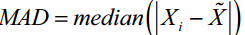
#### That is, we take the median of the absolute value of differences between individual values and the median of our set. Because our median is 8.75, we subtract 8.75 from each of the collection items and take its absolute value, leaving us with { 1.45, 0.55, 0.35, 0.35, 0.55, 0.85 }. The median of this collection is 0.55.

### Control Charts
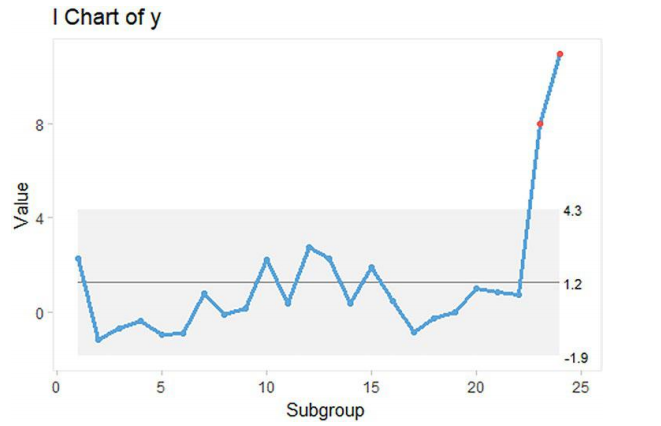

# Laying Out the Framework 
## Making Plumbing Choices 
#### We should make a few decisions about how our end users will interact with the service. The first question we should ask is, why do our customers need this service? The more we understand what kinds of problems they want to solve, the better we can tailor our service to fit their needs. For our scenario, let's suppose that our end users wish to call our service and get a response back in near real time, rather than sending in large datasets and requesting batch operations over the entire dataset. The techniques we will use throughout the book will work just as well for both situations, but how we expose our service to the outside world will differ dramatically as a result of this decision
#### Given that we wish to allow end users to interact in a real-time scenario, we will likely wish to use HyperText Transfer Protocol as our transfer mechanism of choice. We could alternatively design our own solution using Transimission Control Protocol (TCP) sockets, but this would add a significant amount of development overhead to creating a solution and would require that our users develop custom clients to interact with our service.
#### Sticking with HTTP as our protocol of choice, we now have two primary options for how we create services, both of which have a significant amount of support in Python: the Remote Procedure Call framework gRPC or building a Representational State Transfer (REST) API using JavaScript Object Notation (JSON) to pass data back and forth between our service and the client. 
- #### The gRPC-based solution has some significant advantages, starting with payload size. Payloads in gRPC are in the Protocol Buffer (Protobuf) format, a binary format that compacts down request sizes pretty well
- #### By contrast, JSON is a relatively large, uncompressed text format. JSON is more compact than other formats like Extensible Markup Language (XML), but there can be a significant difference in payload size between Protobuf and JSON, especially in batch processing scenarios. 
- #### We also have strict contracts when working with gRPC, meaning that clients know exactly what the server will provide, what parameters and meaning that clients know exactly what the server will provide, what parameters and flags exist, and how to form requests. 
- #### For the purpose of this book, we will choose to work with a REST API using JSON. There are three reasons for this choice. First, working with REST allows us to use freely available tools to interact with our service, including web browsers. The gRPC framework has very limited support for browser-based interaction, whereas REST works natively with browsers. The second reason for choosing REST over gRPC is that a REST API with JSON support provides us human-readable requests, making it easier for humans to parse and interpret requests and correct potential bugs in the client or the service. The final reason we will use REST APIs over gRPC is that more developers are familiar with the former than the latter. 
## Reducing Architectural Variables
- #### There are several Python-based frameworks to make API development easy, including Flask and FastAPI. Flask is a venerable package for core API development and integrates well with proxy solutions like Gunicorn. FastAPI, meanwhile, is a newer solution that has a lot going for it, including great performance and automatic implementation of the OpenAPI specification using a tool called ReDoc.
- #### Beyond this, we can also use Docker containers to deploy the application. That way, no matter which operating system u are running or what libraries you have installed, you can easily deploy the end solution. Using the container version of the solution we build is optional, but if u do have Docker installed and want to simplify the dependency management process,u can use it


## Developing an initial framework
### Battlespace Preparation 
#### The repository includes several folders. The \doc\ folder includes basic documentation about the project, including how to run different parts of the project. The \src\app\ folder includes the completed version of the code base we will work throughout the book to create. The \src\comp\ folder includes comparison work we will cover in the final chapter of this book. The \src\web\ folder includes a companion website we will create and update throughout the book. Leaving the \src\ directory altogether, the \test\ folder features two separate sets of tests: one set of unit tests and one set of integration tests. Finally, we have a Dockerfile for people who wish to run the solution as a Docker container, as well as a requirements.txt file.

### Framing the API 
- #### __init__.py, will let the python interpreter know that our app folder contains code for a Python module.
- #### main.py will be the entry point for our API 
- three good options for the editor of choice are VSC, Wing IDE and PyCharm, spyder 
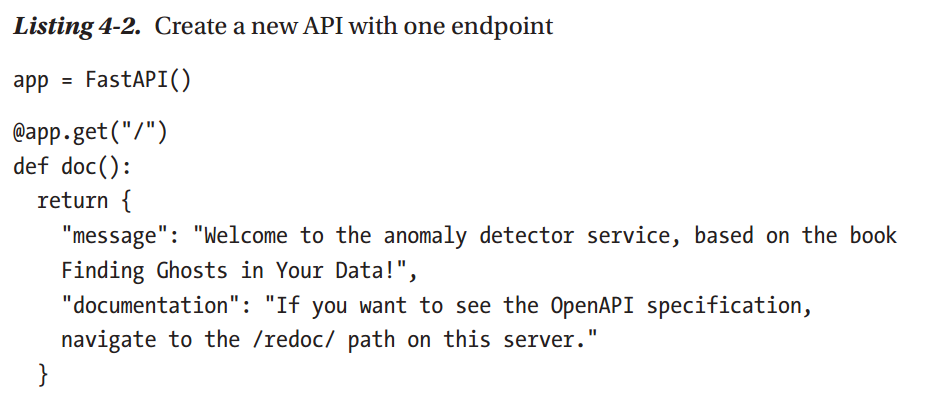

- In this block of code, we first create a new API service called app. We then create a new endpoint for our application at the root directory. This endpoint accepts the GET method in REST. The GET method does not take a request body, and it is expected to return something. When navigating to web pages or clicking links using a browser, the browser translates these statements to GET operations.
- After defining the endpoint, we now need to write out what our code should do if someone were to call that endpoint. In this case, we return a message. The message must be a valid JSON. In this case, we create a JSON object with two attributes: message and documentation. 
Now, that we have a functional API service, the next step is to lay out the input and output signatures we will need throughout the book 
### Input and Output Signatures
- #### Each API endpoint will need its own specific input and output structure. 